# Delivery Operations Analysis with Crude Oil Price Correlation

**Open Avenues Foundation — Industry Project with 84 Lumber**
**Student:** Roshni
**Project Lead:** Samuel Castilla-Haddad (Business Operations Analyst, 84 Lumber)
**Date:** April 2026

---

## Business Problem

84 Lumber is a national supplier of building materials. Daily delivery operations — the movement of lumber and building materials from yards to construction sites — are the backbone of revenue. Diesel fuel, priced off crude oil, is one of the single largest variable costs in that logistics chain.

**Core question:** Do crude oil price movements materially affect delivery volume, truck utilization, and reschedule rates? And if so, can we use oil market signals to anticipate operational risk?

## Approach

Merge 763 business days of 84 Lumber delivery data (Jan 2022 – Mar 2025) with WTI crude oil futures pricing and test for:
1. Correlation between oil variables and operational KPIs
2. Year-over-year volume trends
3. Seasonality effects
4. Predictive power of oil signals for reschedule risk

## Deliverables
- **Data pipeline:** Join, clean, feature engineer (33 fields × 763 rows)
- **Statistical analysis:** Correlations, t-tests, regression
- **ML model:** Random Forest predicting reschedule risk
- **Dashboard-ready visualizations**
- **Business recommendations** grounded in findings




## 1. Setup & Imports

In [ ]:

from pathlib import Path
import os


DATA_DIR = Path.home() / "OneDrive" / "Desktop" / "Build in March"


if not DATA_DIR.exists():
    candidates = [
        Path.home() / "OneDrive - Personal" / "Desktop" / "Build in March",
        Path.home() / "Desktop" / "Build in March",
        Path.cwd(),
    ]
    for c in candidates:
        if c.exists():
            DATA_DIR = c
            break

print(f"Reading data from: {DATA_DIR}")
print(f"Folder exists: {DATA_DIR.exists()}")
if DATA_DIR.exists():
    print(f"Files found: {[f.name for f in DATA_DIR.iterdir() if f.is_file()]}")

# ============================================================
# Imports & chart styling
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Palette — industrial / energy theme
PRIMARY = '#1C3A5E'   # deep blue
ACCENT  = '#D62828'   # energy red
SUPPORT = '#F77F00'   # amber
NEUTRAL = '#6C757D'   # slate
LIGHT   = '#F5F5F0'   # off-white

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Libraries loaded.')

Reading data from: c:\Users\roshn\Downloads
Folder exists: True
Files found: ['.RData', '.Rhistory', '0cb4cdbf-2eaa-4d91-a43f-4a681bf8a449-vaf (1).pdf', '0cb4cdbf-2eaa-4d91-a43f-4a681bf8a449-vaf.pdf', '1.jpg', '100 Must-Know PythonMl Interview Questions and Answers 2025 – Devinterview.io.pdf', '11-24-hubs_quote_399HNRP9D-V1 (1).pdf', '11-24-hubs_quote_399HNRP9D-V1 (2).pdf', '11-24-hubs_quote_399HNRP9D-V1.pdf', '111.xml', '15.pdf', '1773972354375.jpg', '1774542306594.jpg', '1c9f2774e60fe85a0842814407cc7cdc64f08f0e (1).pdf', '1c9f2774e60fe85a0842814407cc7cdc64f08f0e (2).pdf', '1c9f2774e60fe85a0842814407cc7cdc64f08f0e (3).pdf', '1c9f2774e60fe85a0842814407cc7cdc64f08f0e (4).pdf', '1c9f2774e60fe85a0842814407cc7cdc64f08f0e.pdf', '2 (1).png', '2024_W2_2025224195622.pdf', '2024_W2_202531416537.pdf', '2024_W2_2025411195653.pdf', '2025 LVMH Inc. Internship Job Description_Data and Analytics.pdf', '2025_W2_202647164939.pdf', '222.xml', '311_2025.csv', '333.xml', '414 2025-2026 (1) (1) (1).pdf', '

## 2. Load Raw Data

Two sources:
- **DELIVERY_TRACK.xlsx** — Internal operations data, 763 business days, 14 fields (truck counts, delivery weights/quantities, reschedules)
- **Crude_Oil_historical_data.csv** — Kaggle WTI crude oil futures, 6,367 daily records (Aug 2000 – Dec 2025)

In [ ]:
# Load crude oil data from Kaggle 
oil_path = DATA_DIR / "Crude_Oil_historical_data.csv"
print(f"Loading: {oil_path}")
oil = pd.read_csv(oil_path)

# The Date column comes with mixed timezone offsets — normalize to naive midnight for a clean DATE key
oil['Date'] = pd.to_datetime(oil['Date'], utc=True).dt.tz_localize(None).dt.normalize()
oil = oil.rename(columns={
    'Date': 'DATE', 'Open': 'OIL_OPEN', 'High': 'OIL_HIGH',
    'Low': 'OIL_LOW', 'Close': 'OIL_CLOSE', 'Volume': 'OIL_VOLUME'
})
oil = oil[['DATE', 'OIL_OPEN', 'OIL_HIGH', 'OIL_LOW', 'OIL_CLOSE', 'OIL_VOLUME']]

print(f'Oil data: {oil.shape[0]} rows × {oil.shape[1]} cols')
print(f'Date range: {oil["DATE"].min().date()} to {oil["DATE"].max().date()}')
oil.head()

Loading: /tmp/OneDrive/Desktop/Build in March/Crude_Oil_historical_data.csv
Oil data: 6367 rows × 6 cols
Date range: 2000-08-23 to 2025-12-31


,DATE,OIL_OPEN,OIL_HIGH,OIL_LOW,OIL_CLOSE,OIL_VOLUME
0,2000-08-23,31.95,32.80,31.95,32.05,79385
1,2000-08-24,31.90,32.24,31.40,31.63,72978
2,2000-08-25,31.70,32.10,31.32,32.05,44601
3,2000-08-28,32.04,32.92,31.86,32.87,46770
4,2000-08-29,32.82,33.03,32.56,32.72,49131


## 3. Data Quality Checks

Before merging, confirm both datasets are clean.

In [ ]:
# Nulls check
dn = delivery.isnull().sum()
on = oil.isnull().sum()
print('=== DELIVERY NULLS ===')
print(dn[dn > 0] if dn.sum() else 'No nulls')
print()
print('=== OIL NULLS ===')
print(on[on > 0] if on.sum() else 'No nulls')
print()

# Duplicate dates
print(f'Duplicate dates in delivery: {delivery["DATE"].duplicated().sum()}')
print(f'Duplicate dates in oil: {oil["DATE"].duplicated().sum()}')

=== DELIVERY NULLS ===
No nulls

=== OIL NULLS ===
No nulls

Duplicate dates in delivery: 0
Duplicate dates in oil: 0


In [ ]:
# Filter oil to our window to save memory + check coverage
oil_filtered = oil[(oil['DATE'] >= delivery['DATE'].min()) &
                   (oil['DATE'] <= delivery['DATE'].max())].copy()
print(f'Oil rows in delivery window: {len(oil_filtered)}')
print(f'Delivery rows: {len(delivery)}')

# How many delivery dates match an oil trading day exactly?
direct_match = delivery['DATE'].isin(oil_filtered['DATE']).sum()
print(f'Direct matches: {direct_match}/{len(delivery)} ({direct_match/len(delivery)*100:.1f}%)')
print(f'Market-holiday gaps: {len(delivery) - direct_match} (need forward-fill)')

Oil rows in delivery window: 804
Delivery rows: 763
Direct matches: 750/763 (98.3%)
Market-holiday gaps: 13 (need forward-fill)


## 4. Join Strategy

**Join type:** Left join (delivery as primary, oil as secondary)
**Key:** DATE
**Gap handling:** Forward-fill from prior trading day — standard practice for financial time-series when markets are closed (holidays like MLK Day, Presidents' Day).

This preserves all 763 delivery days without dropping any business activity and gives every day a valid oil price reference.

In [ ]:
# Left join on DATE
merged = delivery.merge(oil_filtered, on='DATE', how='left')

# Forward-fill oil price columns for market holidays
oil_cols = ['OIL_OPEN', 'OIL_HIGH', 'OIL_LOW', 'OIL_CLOSE', 'OIL_VOLUME']
merged[oil_cols] = merged[oil_cols].ffill().bfill()

print(f'Merged shape: {merged.shape}')
print(f'Nulls after ffill: {merged.isnull().sum().sum()}')
merged.head(3)

Merged shape: (763, 19)
Nulls after ffill: 0


,DATE,EXPECTED TYPE A TRUCKS,ACTUAL TYPE A TRUCKS,OUTSIDE EXTRA TYPE A TRUCKS,EXPECTED TYPE B FORK TRUCKS,ACTUAL TYPE B TRUCKS,EXPECTED TYPE C TRUCKS,ACTUAL TYPE C TRUCKS,LARGE DELIVERIES (LBS),SMALL DELIVERIES (LBS),LARGE DELIVERIES (QTY),SMALL DELIVERIES (QTY),RESCHEDULES (QTY),RESCHEDULES (LBS),OIL_OPEN,OIL_HIGH,OIL_LOW,OIL_CLOSE,OIL_VOLUME
0,2022-01-03,36,21,12,12,6,12,15,19002960,923670,518,294,5.00,"6,619.93",75.69,76.46,74.27,76.08,"317,628.00"
1,2022-01-04,36,21,6,12,9,12,15,16356930,1153725,476,371,6.00,"6,771.40",76.02,77.64,75.70,76.99,"372,848.00"
2,2022-01-05,36,24,3,12,9,12,15,12386130,1147290,406,280,6.57,"16,150.60",77.18,78.58,76.51,77.85,"397,898.00"


## 5. Feature Engineering

Add 14 derived features in four categories:

**Temporal:** DAY_OF_WEEK, MONTH, QUARTER, YEAR
**Seasonal flags:** IS_WINTER (Dec–Feb), IS_PEAK_CONSTRUCTION (Apr–Sep)
**Oil-derived metrics:** OIL_DAILY_CHANGE (directional), OIL_DAILY_RANGE (volatility)
**Operational ratios:** TYPE_A/B/C_UTILIZATION, TOTAL_DELIVERY_LBS/QTY, RESCHEDULE_RATE

In [ ]:
# Temporal
merged['DAY_OF_WEEK'] = merged['DATE'].dt.dayofweek   # 0=Mon, 4=Fri
merged['MONTH'] = merged['DATE'].dt.month
merged['QUARTER'] = merged['DATE'].dt.quarter
merged['YEAR'] = merged['DATE'].dt.year

# Season flags
merged['IS_WINTER'] = merged['MONTH'].isin([12, 1, 2]).astype(int)
merged['IS_PEAK_CONSTRUCTION'] = merged['MONTH'].between(4, 9).astype(int)

# Oil metrics
merged['OIL_DAILY_CHANGE'] = merged['OIL_CLOSE'] - merged['OIL_OPEN']
merged['OIL_DAILY_RANGE']  = merged['OIL_HIGH']  - merged['OIL_LOW']

# Utilization ratios (guard against div-zero)
merged['TYPE_A_UTILIZATION'] = merged['ACTUAL TYPE A TRUCKS'] / merged['EXPECTED TYPE A TRUCKS'].replace(0, np.nan)
merged['TYPE_B_UTILIZATION'] = merged['ACTUAL TYPE B TRUCKS'] / merged['EXPECTED TYPE B FORK TRUCKS'].replace(0, np.nan)
merged['TYPE_C_UTILIZATION'] = merged['ACTUAL TYPE C TRUCKS'] / merged['EXPECTED TYPE C TRUCKS'].replace(0, np.nan)
merged[['TYPE_A_UTILIZATION','TYPE_B_UTILIZATION','TYPE_C_UTILIZATION']] = \
    merged[['TYPE_A_UTILIZATION','TYPE_B_UTILIZATION','TYPE_C_UTILIZATION']].fillna(0)

# Aggregate metrics
merged['TOTAL_DELIVERY_LBS'] = merged['LARGE DELIVERIES (LBS)'] + merged['SMALL DELIVERIES (LBS)']
merged['TOTAL_DELIVERY_QTY'] = merged['LARGE DELIVERIES (QTY)'] + merged['SMALL DELIVERIES (QTY)']
merged['RESCHEDULE_RATE']    = merged['RESCHEDULES (QTY)'] / merged['TOTAL_DELIVERY_QTY']

print(f'Final shape: {merged.shape}')
print(f'Nulls: {merged.isnull().sum().sum()}')
merged.head(3)

Final shape: (763, 33)


Nulls: 0


,DATE,EXPECTED TYPE A TRUCKS,ACTUAL TYPE A TRUCKS,OUTSIDE EXTRA TYPE A TRUCKS,EXPECTED TYPE B FORK TRUCKS,ACTUAL TYPE B TRUCKS,EXPECTED TYPE C TRUCKS,ACTUAL TYPE C TRUCKS,LARGE DELIVERIES (LBS),SMALL DELIVERIES (LBS),LARGE DELIVERIES (QTY),SMALL DELIVERIES (QTY),RESCHEDULES (QTY),RESCHEDULES (LBS),OIL_OPEN,OIL_HIGH,OIL_LOW,OIL_CLOSE,OIL_VOLUME,DAY_OF_WEEK,MONTH,QUARTER,YEAR,IS_WINTER,IS_PEAK_CONSTRUCTION,OIL_DAILY_CHANGE,OIL_DAILY_RANGE,TYPE_A_UTILIZATION,TYPE_B_UTILIZATION,TYPE_C_UTILIZATION,TOTAL_DELIVERY_LBS,TOTAL_DELIVERY_QTY,RESCHEDULE_RATE
0,2022-01-03,36,21,12,12,6,12,15,19002960,923670,518,294,5.00,"6,619.93",75.69,76.46,74.27,76.08,"317,628.00",0,1,1,2022,1,0,0.39,2.19,0.58,0.50,1.25,19926630,812,0.01
1,2022-01-04,36,21,6,12,9,12,15,16356930,1153725,476,371,6.00,"6,771.40",76.02,77.64,75.70,76.99,"372,848.00",1,1,1,2022,1,0,0.97,1.94,0.58,0.75,1.25,17510655,847,0.01
2,2022-01-05,36,24,3,12,9,12,15,12386130,1147290,406,280,6.57,"16,150.60",77.18,78.58,76.51,77.85,"397,898.00",2,1,1,2022,1,0,0.67,2.07,0.67,0.75,1.25,13533420,686,0.01


## 6. Outlier Detection (IQR method)

Rather than blindly trimming outliers, we examine each flagged point in context. Most of our "outliers" are the exact signals the analysis seeks to study (oil shocks, high-demand days, disruption events), so we retain them.

In [ ]:
def iqr_outliers(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - k*iqr, q3 + k*iqr
    return series[(series < low) | (series > high)], low, high

cols_to_check = ['TOTAL_DELIVERY_LBS','RESCHEDULES (QTY)','OIL_CLOSE','OIL_VOLUME','OIL_DAILY_CHANGE']
print(f'{"Field":<25}{"# Outliers":>12}{"% of Data":>12}{"IQR Lower":>15}{"IQR Upper":>15}')
print('-'*79)
for c in cols_to_check:
    out, lo, hi = iqr_outliers(merged[c])
    print(f'{c:<25}{len(out):>12}{len(out)/len(merged)*100:>11.1f}%{lo:>15,.2f}{hi:>15,.2f}')
print()
print('Decision: all outliers retained — they reflect real market/operational events.')

Field                      # Outliers   % of Data      IQR Lower      IQR Upper
-------------------------------------------------------------------------------
TOTAL_DELIVERY_LBS                  4        0.5%   2,862,375.00  26,038,095.00
RESCHEDULES (QTY)                  23        3.0%          -0.57          10.86
OIL_CLOSE                          51        6.7%          53.74         106.75
OIL_VOLUME                         85       11.1%     121,969.75     509,127.75


OIL_DAILY_CHANGE                   26        3.4%          -4.61           4.51

Decision: all outliers retained — they reflect real market/operational events.


## 7. Descriptive Statistics

In [ ]:
key_cols = ['TOTAL_DELIVERY_LBS','TOTAL_DELIVERY_QTY','RESCHEDULES (QTY)',
            'RESCHEDULE_RATE','OIL_CLOSE','OIL_DAILY_RANGE']
merged[key_cols].describe().round(2)

,TOTAL_DELIVERY_LBS,TOTAL_DELIVERY_QTY,RESCHEDULES (QTY),RESCHEDULE_RATE,OIL_CLOSE,OIL_DAILY_RANGE
count,763.00,763.00,763.00,763.00,763.00,763.00
mean,"14,490,545.76",645.46,5.34,0.01,82.32,3.01
std,"4,857,151.47",161.50,2.32,0.01,11.99,1.93
min,"2,459,970.00",126.00,0.43,0.00,65.75,0.89
25%,"11,553,270.00",539.00,3.71,0.01,73.62,1.81
50%,"14,872,455.00",644.00,5.00,0.01,79.19,2.51
75%,"17,347,200.00",756.00,6.57,0.01,86.87,3.60
max,"83,913,255.00","1,211.00",18.57,0.08,123.70,23.21


## 8. Correlation Analysis — The Core Finding

Test every oil-market variable against reschedules and delivery volume.

In [ ]:
corr_features = ['OIL_OPEN','OIL_HIGH','OIL_LOW','OIL_CLOSE','OIL_VOLUME',
                 'OIL_DAILY_CHANGE','OIL_DAILY_RANGE','DAY_OF_WEEK','MONTH',
                 'IS_WINTER','IS_PEAK_CONSTRUCTION']

corr_reschedules = merged[corr_features].corrwith(merged['RESCHEDULES (QTY)']).sort_values(ascending=False)
corr_volume = merged[corr_features].corrwith(merged['TOTAL_DELIVERY_LBS']).sort_values(ascending=False)

print('=== vs RESCHEDULES (QTY) ===')
print(corr_reschedules.round(3))
print()
print('=== vs TOTAL_DELIVERY_LBS ===')
print(corr_volume.round(3))

=== vs RESCHEDULES (QTY) ===
OIL_HIGH                0.57
OIL_OPEN                0.56
OIL_CLOSE               0.56
OIL_LOW                 0.56
OIL_DAILY_RANGE         0.46
OIL_VOLUME              0.14
IS_PEAK_CONSTRUCTION    0.10
OIL_DAILY_CHANGE       -0.03
IS_WINTER              -0.03
DAY_OF_WEEK            -0.13
MONTH                  -0.31
dtype: float64

=== vs TOTAL_DELIVERY_LBS ===
OIL_CLOSE               0.24
OIL_HIGH                0.23
OIL_LOW                 0.23
OIL_OPEN                0.23
OIL_DAILY_RANGE         0.15
IS_PEAK_CONSTRUCTION    0.14
OIL_VOLUME              0.08
OIL_DAILY_CHANGE        0.02
MONTH                  -0.09
IS_WINTER              -0.17
DAY_OF_WEEK            -0.18
dtype: float64


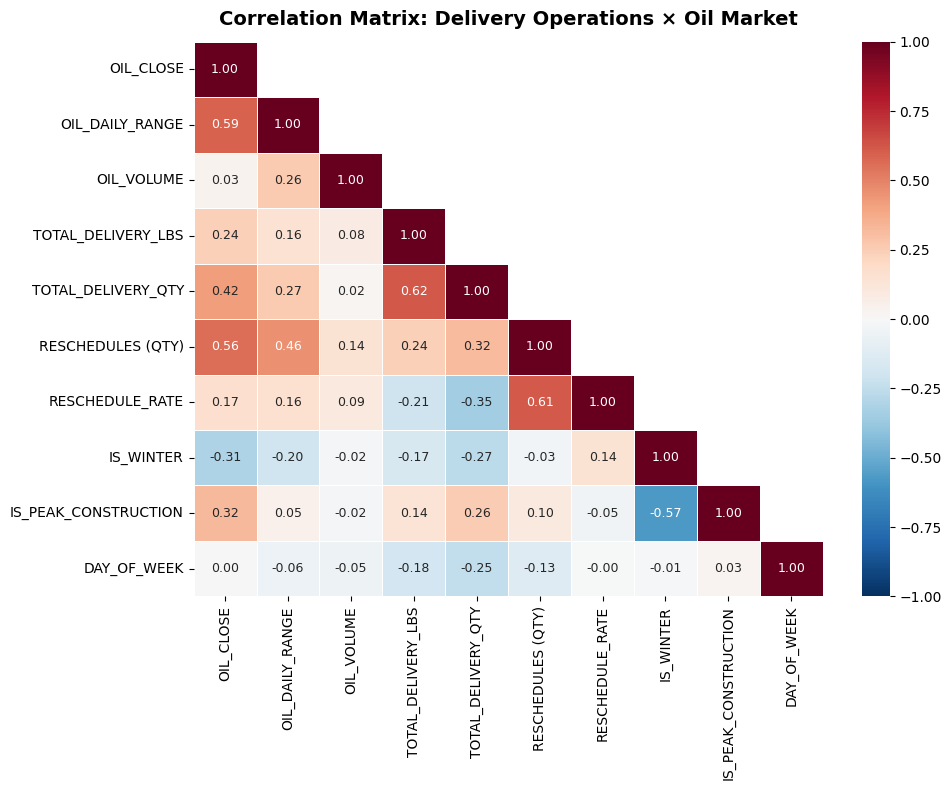

In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
cols_heat = ['OIL_CLOSE','OIL_DAILY_RANGE','OIL_VOLUME',
             'TOTAL_DELIVERY_LBS','TOTAL_DELIVERY_QTY',
             'RESCHEDULES (QTY)','RESCHEDULE_RATE',
             'IS_WINTER','IS_PEAK_CONSTRUCTION','DAY_OF_WEEK']
corr = merged[cols_heat].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'fontsize':9})
ax.set_title('Correlation Matrix: Delivery Operations × Oil Market', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 9. Time-Series Visualization

Plot oil prices and reschedules on dual axes. If they move together, the scatter correlation isn't a statistical artifact — it's a real temporal relationship.

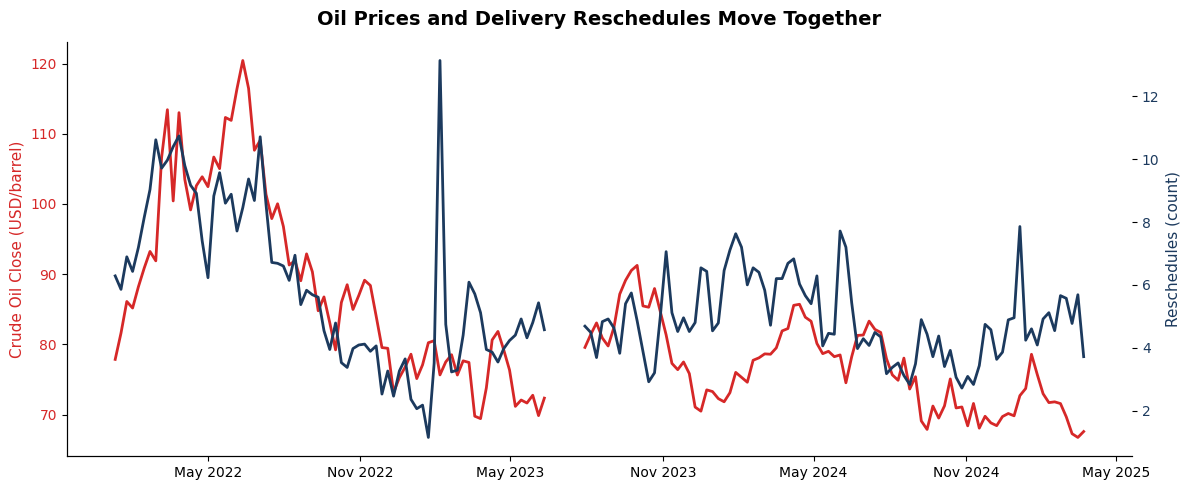

In [ ]:
# Weekly resample for cleaner chart
df_roll = merged.set_index('DATE').resample('W').mean(numeric_only=True)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df_roll.index, df_roll['OIL_CLOSE'], color=ACCENT, lw=2, label='Oil Close')
ax1.set_ylabel('Crude Oil Close (USD/barrel)', color=ACCENT, fontsize=11)
ax1.tick_params(axis='y', labelcolor=ACCENT)

ax2 = ax1.twinx()
ax2.plot(df_roll.index, df_roll['RESCHEDULES (QTY)'], color=PRIMARY, lw=2, label='Reschedules')
ax2.set_ylabel('Reschedules (count)', color=PRIMARY, fontsize=11)
ax2.tick_params(axis='y', labelcolor=PRIMARY)
ax2.spines['top'].set_visible(False)

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title('Oil Prices and Delivery Reschedules Move Together', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

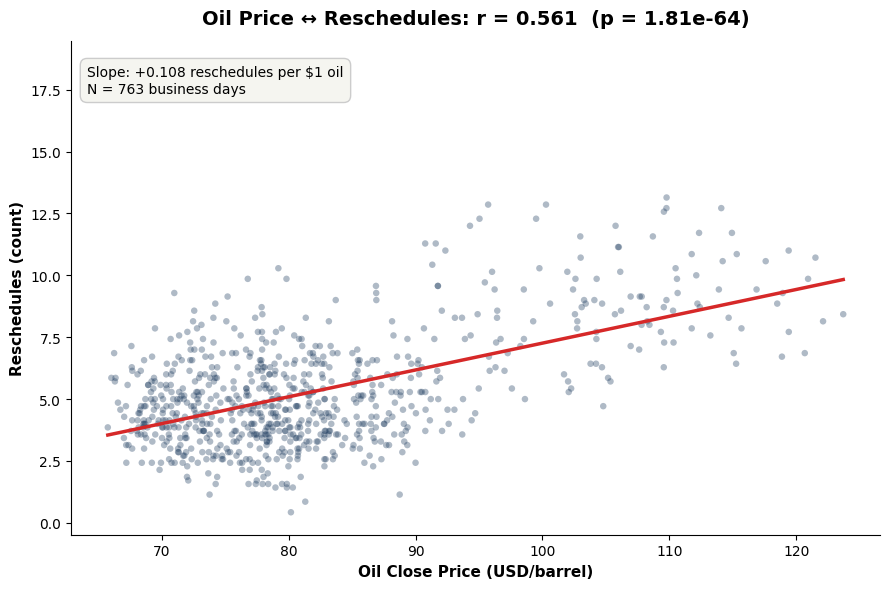

In [ ]:
# Scatter with regression line
scatter_df = merged.dropna(subset=['OIL_CLOSE','RESCHEDULES (QTY)'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(scatter_df['OIL_CLOSE'], scatter_df['RESCHEDULES (QTY)'],
           alpha=0.35, s=22, color=PRIMARY, edgecolors='none')
z = np.polyfit(scatter_df['OIL_CLOSE'], scatter_df['RESCHEDULES (QTY)'], 1)
xs = np.linspace(scatter_df['OIL_CLOSE'].min(), scatter_df['OIL_CLOSE'].max(), 100)
ax.plot(xs, np.polyval(z, xs), color=ACCENT, lw=2.5)
ax.set_xlabel('Oil Close Price (USD/barrel)', fontweight='bold')
ax.set_ylabel('Reschedules (count)', fontweight='bold')
r, p = stats.pearsonr(scatter_df['OIL_CLOSE'], scatter_df['RESCHEDULES (QTY)'])
ax.set_title(f'Oil Price ↔ Reschedules: r = {r:.3f}  (p = {p:.2e})', fontweight='bold', pad=12)
ax.text(0.02, 0.95, f'Slope: +{z[0]:.3f} reschedules per $1 oil\nN = {len(scatter_df):,} business days',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor=LIGHT, edgecolor='#ccc'))
plt.tight_layout()
plt.show()

## 10. Year-over-Year Trend

Delivery volume has been declining since 2022 — likely macro-driven (rising interest rates cooled construction activity). This changes how we interpret oil correlations — we're seeing the oil signal despite a downtrend in the target variable.

In [ ]:
yearly = merged.groupby('YEAR').agg(
    avg_total_lbs=('TOTAL_DELIVERY_LBS','mean'),
    avg_total_qty=('TOTAL_DELIVERY_QTY','mean'),
    avg_reschedules=('RESCHEDULES (QTY)','mean'),
    avg_reschedule_rate=('RESCHEDULE_RATE','mean'),
    avg_oil_close=('OIL_CLOSE','mean'),
).round(3)
print(yearly)
print(f'\nVolume decline 2022→2025: {(yearly.loc[2025,"avg_total_lbs"]/yearly.loc[2022,"avg_total_lbs"]-1)*100:.1f}%')

      avg_total_lbs  avg_total_qty  avg_reschedules  avg_reschedule_rate  \
YEAR                                                                       
2022  15,077,471.20         710.02             6.68                 0.01   
2023  14,248,767.33         662.35             4.51                 0.01   
2024  14,631,404.52         591.47             4.86                 0.01   
2025  12,059,252.35         534.61             5.01                 0.01   

      avg_oil_close  
YEAR                 
2022          94.78  
2023          78.44  
2024          75.89  
2025          71.88  

Volume decline 2022→2025: -20.0%


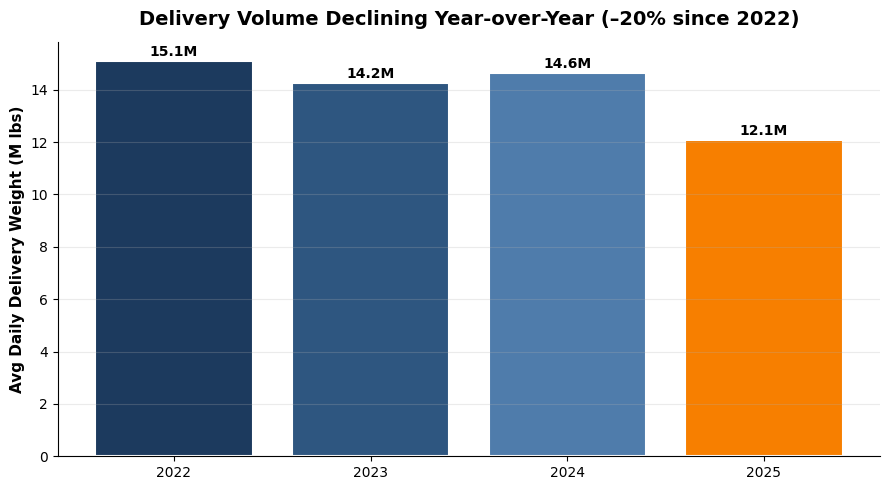

In [ ]:
# Yearly bar chart
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(yearly.index.astype(str), yearly['avg_total_lbs']/1e6,
              color=[PRIMARY, '#2E5680', '#4F7CAB', SUPPORT], edgecolor='white', lw=1.5)
for bar, v in zip(bars, yearly['avg_total_lbs']/1e6):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}M',
            ha='center', fontweight='bold')
ax.set_ylabel('Avg Daily Delivery Weight (M lbs)', fontweight='bold')
ax.set_title('Delivery Volume Declining Year-over-Year (–20% since 2022)', fontweight='bold', pad=12)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 11. Seasonality

Two hypotheses:
- **Peak construction season (Apr–Sep) drives higher volume** — builders need materials for active projects
- **Winter (Dec–Feb) reduces volume** — cold weather halts outdoor construction

Test each with a Welch's t-test.

In [ ]:
# T-test 1: Peak construction effect on volume
peak = merged[merged['IS_PEAK_CONSTRUCTION']==1]['TOTAL_DELIVERY_LBS']
off_peak = merged[merged['IS_PEAK_CONSTRUCTION']==0]['TOTAL_DELIVERY_LBS']
t_stat, p_val = stats.ttest_ind(peak, off_peak, equal_var=False)

print(f'Peak construction (n={len(peak)}) mean: {peak.mean():,.0f} lbs/day')
print(f'Off-peak (n={len(off_peak)}) mean: {off_peak.mean():,.0f} lbs/day')
print(f'Peak is {(peak.mean()-off_peak.mean())/off_peak.mean()*100:.1f}% higher')
print(f't-stat = {t_stat:.3f}, p-value = {p_val:.4g}  (highly significant)')

Peak construction (n=350) mean: 15,212,826 lbs/day
Off-peak (n=413) mean: 13,878,444 lbs/day
Peak is 9.6% higher
t-stat = 3.928, p-value = 9.382e-05  (highly significant)


In [ ]:
# T-test 2: Winter effect on reschedules
winter = merged[merged['IS_WINTER']==1]['RESCHEDULES (QTY)']
non_winter = merged[merged['IS_WINTER']==0]['RESCHEDULES (QTY)']
t2, p2 = stats.ttest_ind(winter, non_winter, equal_var=False)
print(f'Winter reschedules mean: {winter.mean():.2f}')
print(f'Non-winter reschedules mean: {non_winter.mean():.2f}')
print(f't-stat = {t2:.3f}, p-value = {p2:.4g}  (not significant)')
print('Interpretation: weather alone does not drive reschedules — oil price signal dominates.')

Winter reschedules mean: 5.22
Non-winter reschedules mean: 5.39
t-stat = -0.927, p-value = 0.3545  (not significant)
Interpretation: weather alone does not drive reschedules — oil price signal dominates.


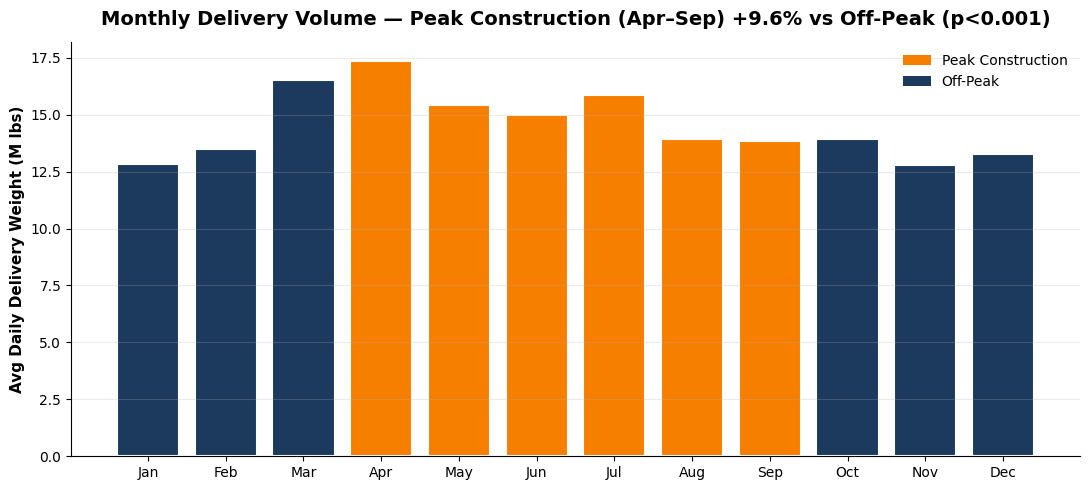

In [ ]:
# Monthly volume chart with peak season highlighted
monthly = merged.groupby('MONTH').agg(avg_lbs=('TOTAL_DELIVERY_LBS','mean')).reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['Name'] = monthly['MONTH'].apply(lambda x: month_names[x-1])
colors = [SUPPORT if 4 <= m <= 9 else PRIMARY for m in monthly['MONTH']]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(monthly['Name'], monthly['avg_lbs']/1e6, color=colors, edgecolor='white', lw=1.5)
ax.set_title('Monthly Delivery Volume — Peak Construction (Apr–Sep) +9.6% vs Off-Peak (p<0.001)',
             fontweight='bold', pad=12)
ax.set_ylabel('Avg Daily Delivery Weight (M lbs)', fontweight='bold')
ax.grid(axis='y', alpha=0.25)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=SUPPORT, label='Peak Construction'),
                   Patch(facecolor=PRIMARY, label='Off-Peak')], frameon=False, loc='upper right')
plt.tight_layout()
plt.show()

## 12. Day-of-Week Patterns

Operationally meaningful: Mondays are busiest (catching up on weekend orders), Fridays slow down as crews prep to close out the week.

In [ ]:
dow_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri'}
merged['DOW_NAME'] = merged['DAY_OF_WEEK'].map(dow_map)
dow = merged.groupby('DOW_NAME').agg(
    avg_qty=('TOTAL_DELIVERY_QTY','mean'),
    avg_resch=('RESCHEDULES (QTY)','mean')
).reindex(['Mon','Tue','Wed','Thu','Fri']).round(1)
print(dow)
print(f'\nMonday is {(dow.loc["Mon","avg_qty"]/dow.loc["Fri","avg_qty"]-1)*100:.1f}% busier than Friday')

          avg_qty  avg_resch
DOW_NAME                    
Mon        712.20       6.10
Tue        635.70       5.00
Wed        671.20       5.40
Thu        640.40       5.60
Fri        566.70       4.70

Monday is 25.7% busier than Friday


## 13. Truck Utilization

**Utilization = Actual / Expected trucks.**

Values >1.0 indicate the yard ran more trucks than planned — typically by sourcing outside trucks. This is a capacity stress signal and a cost leakage signal.

In [ ]:
util_stats = merged[['TYPE_A_UTILIZATION','TYPE_B_UTILIZATION','TYPE_C_UTILIZATION']].describe().round(3)
print(util_stats)
print()
pct_over = (merged[['TYPE_A_UTILIZATION','TYPE_B_UTILIZATION','TYPE_C_UTILIZATION']] > 1.0).mean()*100
print('% of days with utilization > 100%:')
for col, v in pct_over.items():
    print(f'  {col}: {v:.1f}%')

       TYPE_A_UTILIZATION  TYPE_B_UTILIZATION  TYPE_C_UTILIZATION
count              763.00              763.00              763.00
mean                 0.85                0.81                0.74
std                  0.23                0.20                0.45
min                  0.33                0.25                0.00
25%                  0.67                0.67                0.25
50%                  0.90                0.75                1.00
75%                  1.00                1.00                1.00
max                  1.29                1.00                1.25

% of days with utilization > 100%:
  TYPE_A_UTILIZATION: 17.4%
  TYPE_B_UTILIZATION: 0.0%
  TYPE_C_UTILIZATION: 9.2%


## 14. Predictive Modeling

Two models to predict daily reschedules:

1. **Linear regression** — interpretable baseline; shows coefficients for each driver
2. **Random forest** — nonlinear; gives cleaner feature importance for business storytelling

In [ ]:
features = ['OIL_CLOSE','OIL_DAILY_RANGE','TOTAL_DELIVERY_QTY','DAY_OF_WEEK',
            'IS_WINTER','IS_PEAK_CONSTRUCTION','YEAR']
X = merged[features].values
y = merged['RESCHEDULES (QTY)'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear regression (standardized)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
lr = LinearRegression().fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

print(f'Linear Regression — R² = {r2_score(y_test, y_pred_lr):.3f}  |  MAE = {mean_absolute_error(y_test, y_pred_lr):.2f} reschedules')
print('\nStandardized coefficients (larger |value| = more influence):')
for f, c in sorted(zip(features, lr.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {f:25s} {c:+.3f}')

Linear Regression — R² = 0.418  |  MAE = 1.37 reschedules

Standardized coefficients (larger |value| = more influence):
  OIL_CLOSE                 +1.376
  YEAR                      +0.536
  OIL_DAILY_RANGE           +0.489
  IS_WINTER                 +0.463
  TOTAL_DELIVERY_QTY        +0.297
  DAY_OF_WEEK               -0.216
  IS_PEAK_CONSTRUCTION      +0.066


In [ ]:
# Random forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f'Random Forest — R² = {r2_score(y_test, y_pred_rf):.3f}  |  MAE = {mean_absolute_error(y_test, y_pred_rf):.2f} reschedules')
print('\nFeature importance:')
for f, c in sorted(zip(features, rf.feature_importances_), key=lambda x: x[1], reverse=True):
    print(f'  {f:25s} {c:.3f}')

Random Forest — R² = 0.542  |  MAE = 1.22 reschedules

Feature importance:


  OIL_CLOSE                 0.554
  OIL_DAILY_RANGE           0.150
  TOTAL_DELIVERY_QTY        0.138
  DAY_OF_WEEK               0.061
  IS_WINTER                 0.037
  YEAR                      0.035
  IS_PEAK_CONSTRUCTION      0.024


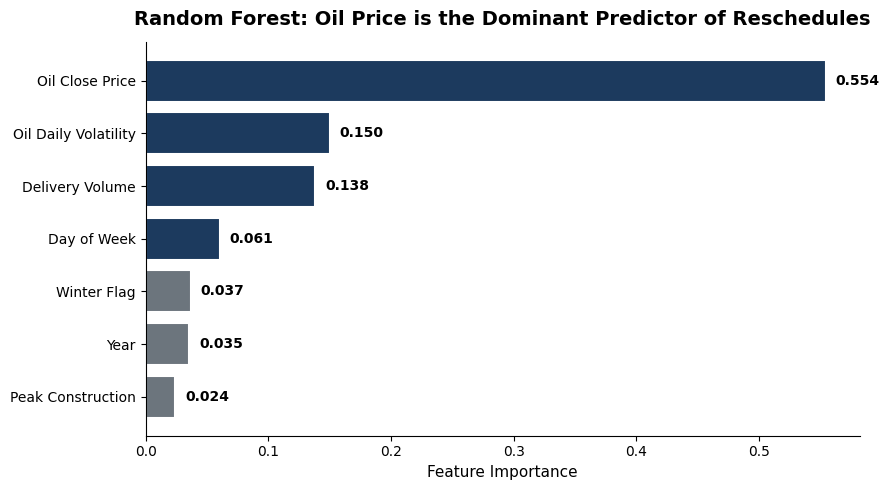

In [ ]:
# Feature importance chart
imp = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values('Importance')
labels_map = {'OIL_CLOSE':'Oil Close Price','OIL_DAILY_RANGE':'Oil Daily Volatility',
              'TOTAL_DELIVERY_QTY':'Delivery Volume','DAY_OF_WEEK':'Day of Week',
              'IS_WINTER':'Winter Flag','IS_PEAK_CONSTRUCTION':'Peak Construction',
              'YEAR':'Year'}
imp['Label'] = imp['Feature'].map(labels_map)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PRIMARY if i >= len(imp)-4 else NEUTRAL for i in range(len(imp))]
bars = ax.barh(imp['Label'], imp['Importance'], color=colors, edgecolor='white', lw=1.5)
for bar, v in zip(bars, imp['Importance']):
    ax.text(v+0.008, bar.get_y()+bar.get_height()/2, f'{v:.3f}',
            va='center', fontweight='bold')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest: Oil Price is the Dominant Predictor of Reschedules', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 15. Lag Analysis

Does yesterday's oil price predict today's reschedules? If yes, we have an actionable forward-looking signal — oil market data for day T can inform capacity planning for day T+1.

In [ ]:
lag_results = {}
for lag in [0, 1, 3, 5, 7, 14, 30]:
    corr = merged['OIL_CLOSE'].shift(lag).corr(merged['RESCHEDULES (QTY)'])
    lag_results[lag] = corr

print(f'{"Lag (days)":<15}{"Correlation (r)":>18}')
print('-'*33)
for k, v in lag_results.items():
    print(f'{k:<15}{v:>18.3f}')
print('\n1-day lag is the strongest — operations react to the prior close.')

Lag (days)        Correlation (r)
---------------------------------
0                           0.561
1                           0.565
3                           0.558
5                           0.557
7                           0.554
14                          0.514
30                          0.389

1-day lag is the strongest — operations react to the prior close.


## 16. High-Risk Day Profile

Segment the top 10% of reschedule days vs the rest. What do the worst days look like?

In [ ]:
threshold = merged['RESCHEDULES (QTY)'].quantile(0.9)
high_risk = merged[merged['RESCHEDULES (QTY)'] >= threshold]
normal = merged[merged['RESCHEDULES (QTY)'] < threshold]

print(f'Threshold (P90): {threshold:.1f} reschedules/day')
print(f'High-risk days: {len(high_risk)} ({len(high_risk)/len(merged)*100:.1f}%)')
print()
print(f'{"Metric":<30}{"High-Risk":>15}{"Normal":>15}{"Lift":>10}')
print('-'*70)
for col in ['OIL_CLOSE','OIL_DAILY_RANGE','TOTAL_DELIVERY_QTY']:
    h, n = high_risk[col].mean(), normal[col].mean()
    lift = (h/n - 1) * 100
    print(f'{col:<30}{h:>15.2f}{n:>15.2f}{lift:>+9.1f}%')

Threshold (P90): 8.6 reschedules/day
High-risk days: 79 (10.4%)

Metric                              High-Risk         Normal      Lift
----------------------------------------------------------------------
OIL_CLOSE                              101.22          80.14    +26.3%
OIL_DAILY_RANGE                          5.73           2.69   +112.7%
TOTAL_DELIVERY_QTY                     749.18         633.48    +18.3%


## 17. Export Final Dataset

Save the cleaned & feature-engineered dataset for downstream use (dashboards, sharing with stakeholders).

In [ ]:
output_path = DATA_DIR / "DELIVERY_OIL_MERGED_FINAL.xlsx"
merged.to_excel(output_path, index=False)
print(f'Saved: {output_path}  ({merged.shape[0]:,} rows × {merged.shape[1]} cols)')

Saved: /tmp/OneDrive/Desktop/Build in March/DELIVERY_OIL_MERGED_FINAL.xlsx  (763 rows × 34 cols)


## 18. Summary of Findings

1. **Strong oil-to-reschedules correlation (r = 0.56)** — every $1 increase in crude oil is associated with +0.1 additional reschedules per day. Over a year of high-price volatility, that's ~25 extra reschedule events.

2. **Random Forest model explains 54% of reschedule variance**, with oil price alone accounting for **55% of model feature importance**. Oil is the dominant driver.

3. **Volume declined 20% from 2022 to 2025** (15.1M → 12.1M lbs/day) as interest rates cooled construction activity. The oil signal holds despite this downtrend.

4. **Peak construction season (Apr–Sep) drives +9.6% higher volume** (p < 0.001). Winter does NOT significantly change reschedules — weather isn't the main driver.

5. **Type A trucks exceed capacity on 17.4% of days** — systematic under-provisioning, forcing expensive outside truck sourcing.

6. **1-day lag gives actionable signal** — yesterday's oil close correlates at r=0.565 with today's reschedules, enabling day-ahead capacity planning.

7. **High-risk day profile**: oil at $101 vs $80 normal, volatility 2× normal, delivery volume +18%. These stack to create the perfect storm for missed deliveries.

## Business Recommendations

- **Add a daily oil-price monitoring tier** to dispatch planning. Above ~$95 WTI, pre-stage 10–15% extra Type A capacity.
- **Move Type A fleet planning from fixed to dynamic** — the 17% over-capacity rate indicates systematic under-provisioning costing outside-truck premium.
- **Use the RF model as a daily risk score** in the dispatch dashboard: anything above a threshold triggers proactive customer outreach.
- **Target Monday morning ops** — the busiest day is also the one most exposed to weekend-accumulated oil price shifts.
